In [2]:
import US_indices.composite_portfolio_analysis_Buy_and_Hold as cpa
import US_indices.profit_booking as pb
from importlib import reload
reload(cpa)
reload(pb)


from US_indices.composite_portfolio_analysis_Buy_and_Hold import compare_portfolios

In [31]:
profit_booking = {
    "method": "cagr_percentile",
    "window_years": 5,
    "percentile": 95,
    "reentry_percentile": 20,
    "trim_pct": 0.80,
    "min_days_between": 252,
    "reentry_min_days_between": 0,
    "percentile_mode": "full_history",  # look-ahead bias
    "trading_days_per_year": 252
}

cash_config = {
    "type": "fixed_rate",
    "annual_rate": 0.04
}
# or
cash_config = {
    "type": "series",
    "series_name": "US 3M T-Bill Index"
}

 COMPARING 3 PORTFOLIOS
 Unique indices needed: 6
   - RAFI Dynamic Multi-Factor Developed ex US Index
   - RAFI Dynamic Multi-Factor US Index
   - RAFI Fundamental High Liquidity Developed ex US Large Index
   - RAFI Fundamental High Liquidity Emerging Markets Large Index
   - RAFI Fundamental High Liquidity US Large Index
   - RAFI Fundamental High Liquidity US Small Index

📂 Loading index data...

✅ Global common date grid: 1996-04-02 to 2026-03-20 (7536 days)

[1/3] Processing: Intl 3.5% FD
------------------------------------------------------------
✅ Successfully processed: Intl 3.5% FD

[2/3] Processing: Intl T-bill
------------------------------------------------------------
✅ Successfully processed: Intl T-bill

[3/3] Processing: Intl 2 yr Rebal
------------------------------------------------------------
✅ Successfully processed: Intl 2 yr Rebal

📊 COMBINED SUMMARY - ALL PORTFOLIOS (COMMON DATES)
                               Date Range Total Return % CAGR % Annualized Volat

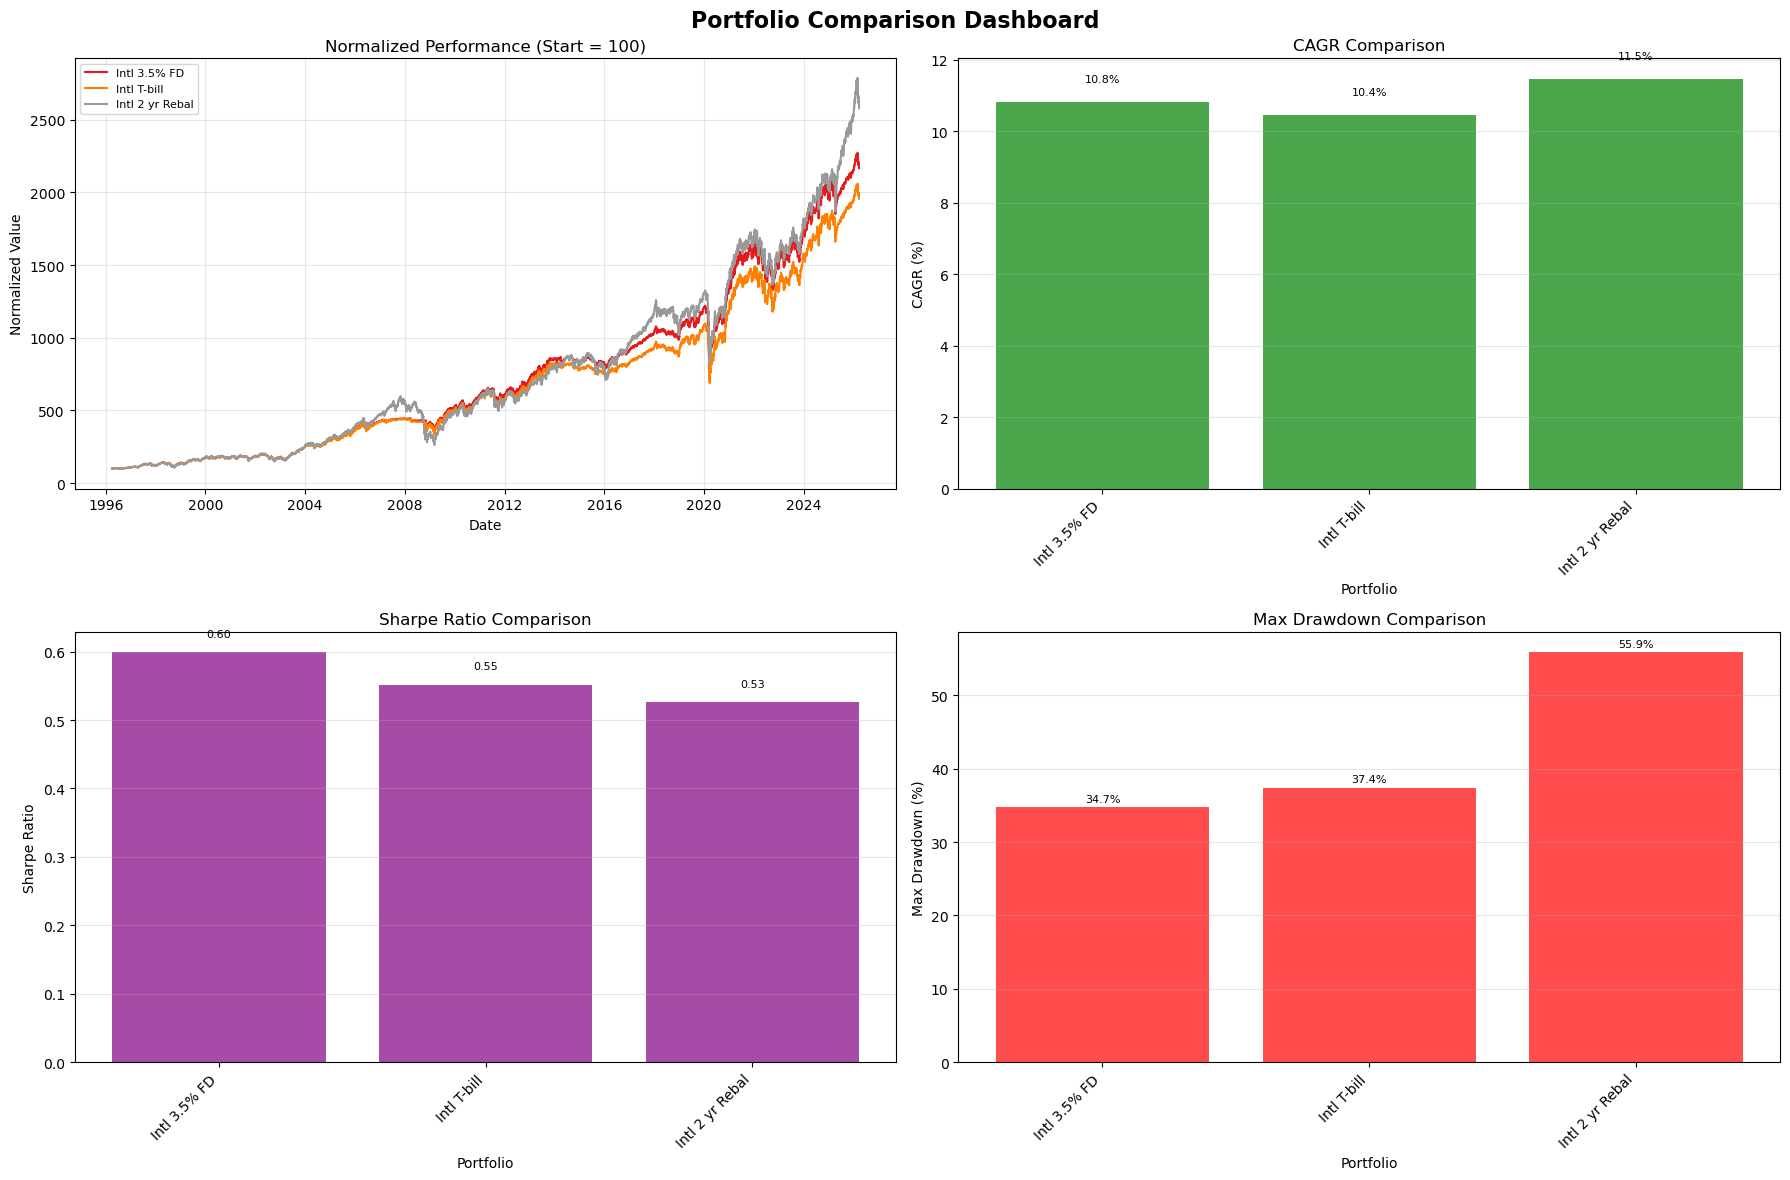

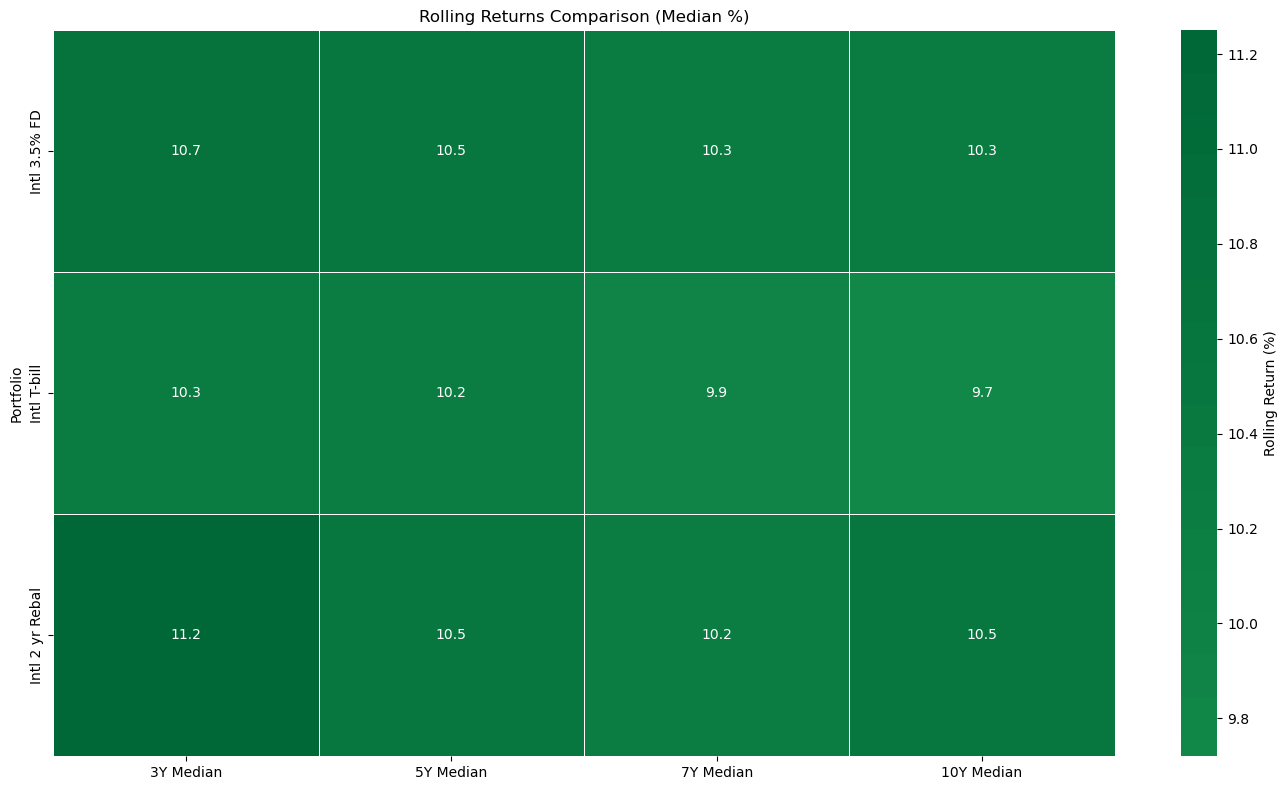

📊 Precomputing rolling returns for all periods...
   Computing 3Y rolling returns...
   Computing 4Y rolling returns...
   Computing 5Y rolling returns...
   Computing 7Y rolling returns...
   Computing 10Y rolling returns...
✅ Precomputation complete!

 INTERACTIVE RUNNING CAGR PLOT
Rolling periods available: [3, 4, 5, 7, 10]
Use the slider below to select the rolling period
--------------------------------------------------------------------------------


interactive(children=(SelectionSlider(description='Rolling Period (years):', layout=Layout(width='500px'), opt…


📑 PROFIT BOOKING HISTORY: Intl 3.5% FD
   Portfolio       Date          Event                                                        Asset  Percentile  CAGR  Units Sold  Units Bought    Value  Cash After  ST Gain  LT Gain  ST Loss  LT Loss
Intl 3.5% FD 2001-05-01 profit_booking               RAFI Fundamental High Liquidity US Large Index       95.03 18.66    0.000217           NaN 0.326741    0.326741      0.0 0.186741      0.0      0.0
Intl 3.5% FD 2002-07-22        reentry               RAFI Fundamental High Liquidity US Large Index       16.52  5.49         NaN      0.000270 0.316993    0.000000      NaN      NaN      NaN      NaN
Intl 3.5% FD 2003-10-14 profit_booking               RAFI Fundamental High Liquidity US Small Index       96.02 21.92    0.000205           NaN 0.383045    0.383045      0.0 0.263045      0.0      0.0
Intl 3.5% FD 2004-05-07        reentry               RAFI Fundamental High Liquidity US Large Index       19.41  6.10         NaN      0.000006 0.009747    

In [32]:
# Define two portfolio options
portfolios_to_compare = [
        {    # without GARP
        'name': 'Intl 3.5% FD',  # US:Em:Dev
        'weights': [
            # US
            ('RAFI Fundamental High Liquidity US Small Index', 0.15),
            ('RAFI Dynamic Multi-Factor US Index', 0.175),
            ('RAFI Fundamental High Liquidity US Large Index', 0.175),
            # Em
            ('RAFI Fundamental High Liquidity Emerging Markets Large Index', 0.25),
            # Dev ex US
            ('RAFI Fundamental High Liquidity Developed ex US Large Index', 0.125),
            ('RAFI Dynamic Multi-Factor Developed ex US Index', 0.125),
        ],
        "profit_booking": profit_booking,
        "cash_config": {"type": "fixed_rate", "annual_rate": 0.035},
        "tax_config": "offshore_equity",
    },
            {    # without GARP
        'name': 'Intl T-bill',  # US:Em:Dev
        'weights': [
            # US
            ('RAFI Fundamental High Liquidity US Small Index', 0.15),
            ('RAFI Dynamic Multi-Factor US Index', 0.175),
            ('RAFI Fundamental High Liquidity US Large Index', 0.175),
            # Em
            ('RAFI Fundamental High Liquidity Emerging Markets Large Index', 0.25),
            # Dev ex US
            ('RAFI Fundamental High Liquidity Developed ex US Large Index', 0.125),
            ('RAFI Dynamic Multi-Factor Developed ex US Index', 0.125),
        ],
        "profit_booking": profit_booking,
        "cash_config": {"type": "series", "series_name": "US 3M T-Bill Index"},
        "tax_config": "offshore_equity",
    },

    # {    # without GARP
    #     'name': 'P1 : NoRebalance',  # US:Em:Dev
    #     'weights': [
    #         # US
    #         ('RAFI Fundamental High Liquidity US Small Index', 0.15),
    #         ('RAFI Dynamic Multi-Factor US Index', 0.175),
    #         ('RAFI Fundamental High Liquidity US Large Index', 0.175),
    #         # Em
    #         ('RAFI Fundamental High Liquidity Emerging Markets Large Index', 0.25),
    #         # Dev ex US
    #         ('RAFI Fundamental High Liquidity Developed ex US Large Index', 0.125),
    #         ('RAFI Dynamic Multi-Factor Developed ex US Index', 0.125),
    #     ],
    #     "rebalance": "no_rebalance",
    # },
    {    # without GARP
        'name': 'Intl 2 yr Rebal',  # US:Em:Dev
        'weights': [
            # US
            ('RAFI Fundamental High Liquidity US Small Index', 0.15),
            ('RAFI Dynamic Multi-Factor US Index', 0.175),
            ('RAFI Fundamental High Liquidity US Large Index', 0.175),
            # Em
            ('RAFI Fundamental High Liquidity Emerging Markets Large Index', 0.25),
            # Dev ex US
            ('RAFI Fundamental High Liquidity Developed ex US Large Index', 0.125),
            ('RAFI Dynamic Multi-Factor Developed ex US Index', 0.125),
        ],
        "rebalance": {"method": "interval", "interval_years": 2},
        "tax_config": "offshore_equity",
    },

]
# Run the comparison
summary = compare_portfolios(
    portfolios_to_compare,
    risk_free_rate=3.5,
    sip_amount=2125,
    show_plots=False,
    export_csv=False,
    search_path='.',          # where your CSV files are
    recursive=True,
    output_fname="example",
    # start_date=None,        # new
    # end_date=None
    # start_date='2010-01-01',
    # end_date='2010-01-01',        # new
    data_format='auto',
    plot_running_cagr=True,
    running_cagr_periods=[3,4,5,7,10],
    # running_cagr_periods=[2,3,4,5],
    plot_running_xirr=False,
    plot_rolling_returns_percentiles=True,
    rolling_percentiles_to_show=[0,5, 10, 25, 50, 75, 80,85, 90, 95,100],
    display_rolling_returns_table=False,
    interactive_cagr=True,
    plot_rebalance_marks=False,
    show_rebalance_history=False,
    show_profit_booking_history=True,
    
)


 COMPARING 4 PORTFOLIOS
 Unique indices needed: 1
   - RAFI Fundamental Select Developed ex US 1000 Index

📂 Loading index data...

✅ Global common date grid: 1984-04-03 to 2026-03-20 (10877 days)

[1/4] Processing: PB: 5yr 95-20
------------------------------------------------------------
✅ Successfully processed: PB: 5yr 95-20

[2/4] Processing: PB: 4yr 80-25
------------------------------------------------------------
✅ Successfully processed: PB: 4yr 80-25

[3/4] Processing: PB: 4yr 80/25 50%
------------------------------------------------------------
✅ Successfully processed: PB: 4yr 80/25 50%

[4/4] Processing: B&H: Dev-ex-US
------------------------------------------------------------
✅ Successfully processed: B&H: Dev-ex-US

📊 COMBINED SUMMARY - ALL PORTFOLIOS (COMMON DATES)
                                 Date Range Total Return % CAGR % Annualized Volatility % Sharpe Ratio Max Drawdown % SIP XIRR % SIP Return % SIP Invested Amt SIP Final Amt Start Value End Value Positive D

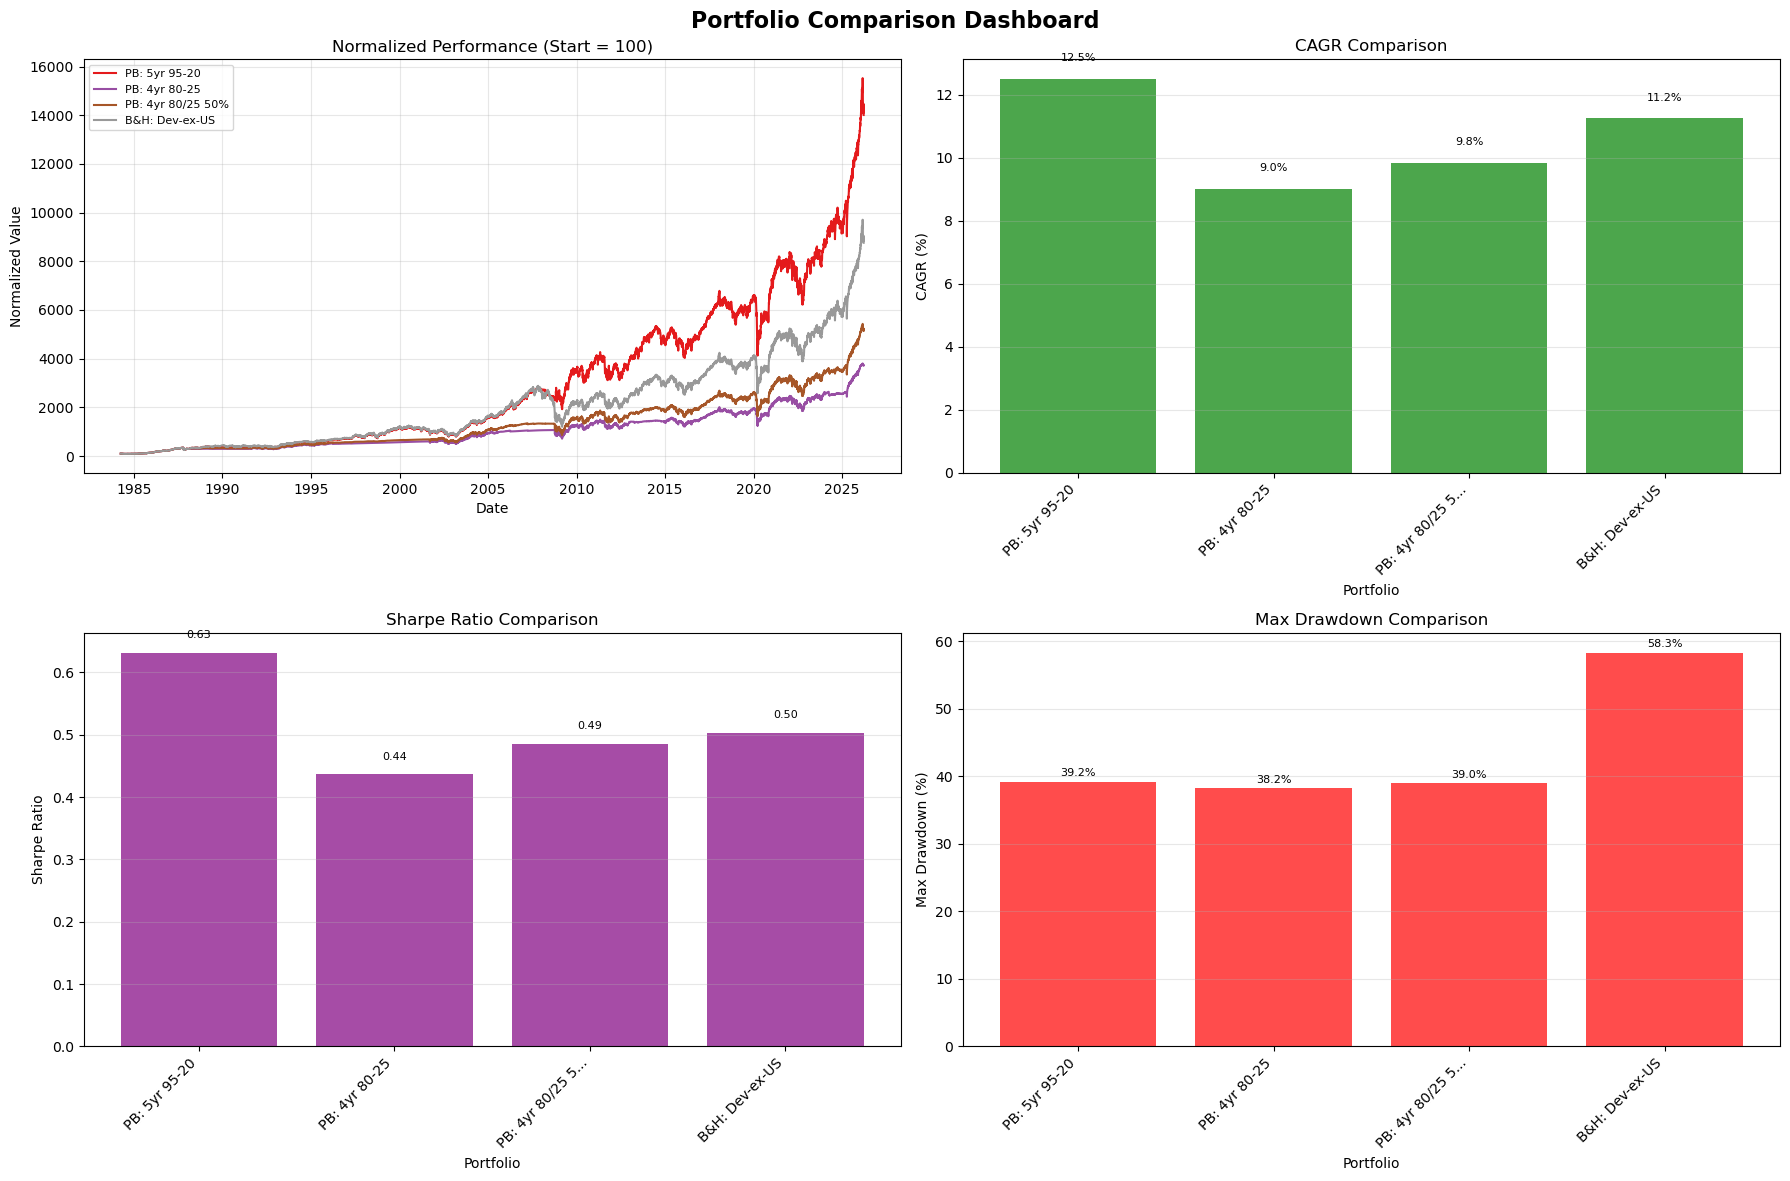

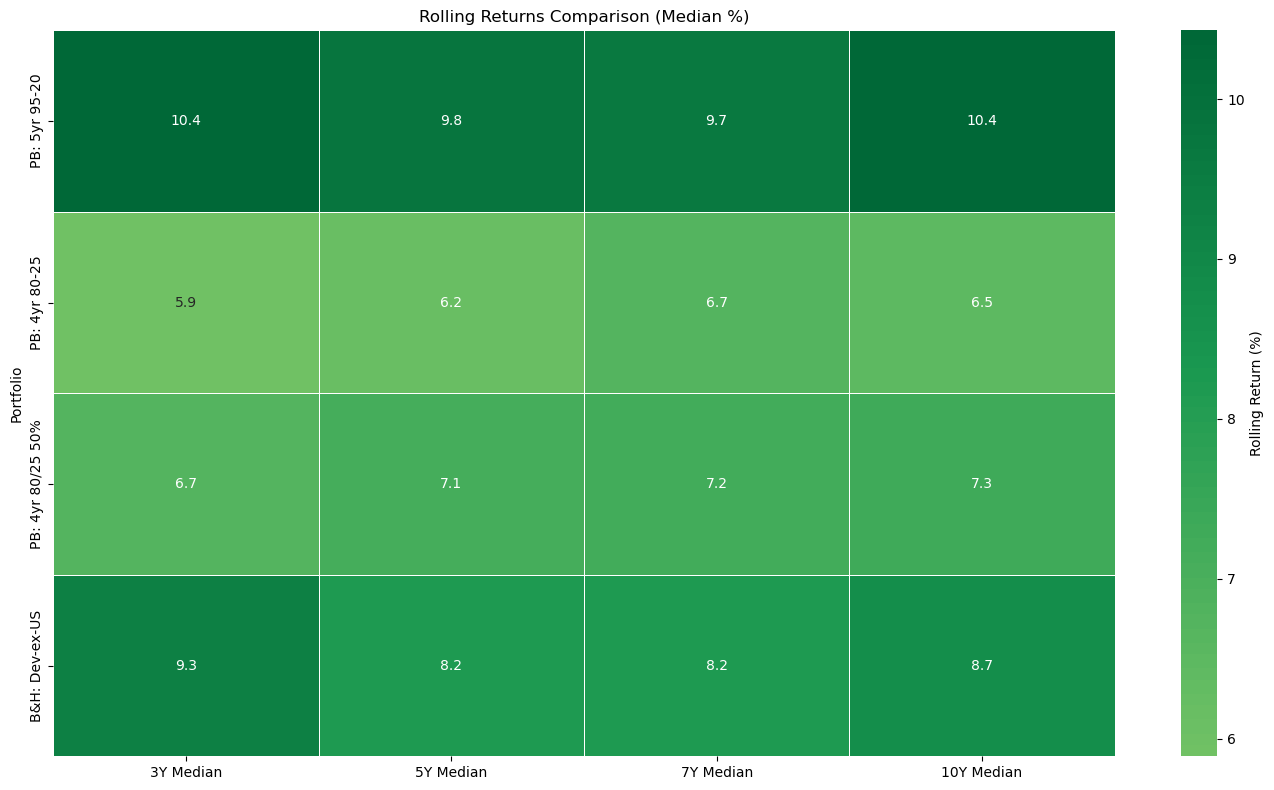

📊 Precomputing rolling returns for all periods...
   Computing 3Y rolling returns...
   Computing 4Y rolling returns...
   Computing 5Y rolling returns...
   Computing 7Y rolling returns...
   Computing 10Y rolling returns...
✅ Precomputation complete!

 INTERACTIVE RUNNING CAGR PLOT
Rolling periods available: [3, 4, 5, 7, 10]
Use the slider below to select the rolling period
--------------------------------------------------------------------------------


interactive(children=(SelectionSlider(description='Rolling Period (years):', layout=Layout(width='500px'), opt…


📑 PROFIT BOOKING HISTORY: PB: 5yr 95-20
    Portfolio       Date          Event                                              Asset  Percentile  CAGR  Units Sold  Units Bought     Value  Cash After  ST Gain   LT Gain  ST Loss  LT Loss
PB: 5yr 95-20 1989-02-17 profit_booking RAFI Fundamental Select Developed ex US 1000 Index       97.54 32.01    0.008000           NaN  3.207293    3.207293      0.0  2.407293      0.0      0.0
PB: 5yr 95-20 1989-10-27 profit_booking RAFI Fundamental Select Developed ex US 1000 Index       98.20 34.21    0.001600           NaN  0.647348    3.553730      0.0  0.487348      0.0      0.0
PB: 5yr 95-20 1990-07-06 profit_booking RAFI Fundamental Select Developed ex US 1000 Index       96.33 29.46    0.000320           NaN  0.138299    3.631110      0.0  0.106299      0.0      0.0
PB: 5yr 95-20 1992-08-12        reentry RAFI Fundamental Select Developed ex US 1000 Index        9.68  2.07         NaN      0.009642  3.676525    0.000000      NaN       NaN      Na

In [13]:
profit_booking = {
    "method": "cagr_percentile",
    "window_years": 5,
    "percentile": 95,
    "reentry_percentile": 10,
    "trim_pct": 0.80,
    "min_days_between": 252,
    "reentry_min_days_between": 0,
    "percentile_mode": "full_history",  # look-ahead bias
    "trading_days_per_year": 252
}

# Define two portfolio options
portfolios_to_compare = [
        {    # without GARP
        'name': 'PB: 5yr 95-20',
        'weights': [
            ('RAFI Fundamental Select Developed ex US 1000 Index', 1),
        ],
        "profit_booking": profit_booking,
        "cash_config": {"type": "series", "series_name": "US 3M T-Bill Index"},
        "tax_config": "offshore_equity",
    },
    {    # without GARP
        'name': 'PB: 4yr 80-25',
        'weights': [
            ('RAFI Fundamental Select Developed ex US 1000 Index', 1),
        ],
        "profit_booking": {
            "method": "cagr_percentile",
            "window_years": 4,
            "percentile": 80,
            "reentry_percentile": 25,
            "trim_pct": 0.80,
            "min_days_between": 252,
            "reentry_min_days_between": 0,
            "percentile_mode": "full_history",  # look-ahead bias
            "trading_days_per_year": 252
        },
        "cash_config": {"type": "series", "series_name": "US 3M T-Bill Index"},
        "tax_config": "offshore_equity",
    },
    {    # without GARP
        'name': 'PB: 4yr 80/25 50%',
        'weights': [
            ('RAFI Fundamental Select Developed ex US 1000 Index', 1),
        ],
        "profit_booking": {
            "method": "cagr_percentile",
            "window_years": 4,
            "percentile": 80,
            "reentry_percentile": 25,
            "trim_pct": 0.50,
            "min_days_between": 252,
            "reentry_min_days_between": 0,
            "percentile_mode": "full_history",  # look-ahead bias
            "trading_days_per_year": 252
        },
        "cash_config": {"type": "series", "series_name": "US 3M T-Bill Index"},
        "tax_config": "offshore_equity",
    },
        {    # without GARP
        'name': 'B&H: Dev-ex-US',
        'weights': [
            ('RAFI Fundamental Select Developed ex US 1000 Index', 1),
        ],
    },

    # {    # without GARP
    #     'name': 'P1 : NoRebalance',  # US:Em:Dev
    #     'weights': [
    #         # US
    #         ('RAFI Fundamental High Liquidity US Small Index', 0.15),
    #         ('RAFI Dynamic Multi-Factor US Index', 0.175),
    #         ('RAFI Fundamental High Liquidity US Large Index', 0.175),
    #         # Em
    #         ('RAFI Fundamental High Liquidity Emerging Markets Large Index', 0.25),
    #         # Dev ex US
    #         ('RAFI Fundamental High Liquidity Developed ex US Large Index', 0.125),
    #         ('RAFI Dynamic Multi-Factor Developed ex US Index', 0.125),
    #     ],
    #     "rebalance": "no_rebalance",
    # },

]
# Run the comparison
summary = compare_portfolios(
    portfolios_to_compare,
    risk_free_rate=3.5,
    sip_amount=1000,
    show_plots=False,
    export_csv=False,
    search_path='.',          # where your CSV files are
    recursive=True,
    output_fname="example",
    # start_date=None,        # new
    # end_date=None
    # start_date='2010-01-01',
    # end_date='2010-01-01',        # new
    data_format='auto',
    plot_running_cagr=True,
    running_cagr_periods=[3,4,5,7,10],
    # running_cagr_periods=[2,3,4,5],
    plot_running_xirr=False,
    plot_rolling_returns_percentiles=True,
    rolling_percentiles_to_show=[0,5, 10, 25, 50, 75, 80,85, 90, 95,100],
    display_rolling_returns_table=False,
    interactive_cagr=True,
    plot_rebalance_marks=False,
    show_rebalance_history=False,
    show_profit_booking_history=True,
    
)
